In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
customer = "Customer_07"
base_folder = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data"
input_folder = os.path.join(base_folder, customer)
output_folder = os.path.join(base_folder, "Plots", customer)
os.makedirs(output_folder, exist_ok=True)

In [12]:
def plot_battery_data(df, title, output_path):
    """Creates a 3x1 subplot to visualize battery discharge and charge data and returns the figure.
    The first subplot is total voltage and SOC vs time.
    The second subplot is temperature vs time.
    The third subplot is individual cell voltages vs time.

    Args:
        df: The battery data to plot
        title: The title to put on top of the complete figure
        output_path: The path of the file where to output the plots

    Returns:
        None
    """
    
    # Identify column groups
    temp_cols = [c for c in df.columns if c.startswith("temperature_M")]
    cell_cols = [c for c in df.columns if c.startswith("cell_voltages_")]

    # === Create 3 subplots ===
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    plt.subplots_adjust(hspace=0.3)

    # Add overall title above all subplots
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)

    # 1. Voltage + SOC vs Time
    ax1 = axs[0]
    ax1.plot(df["time"], df["soc"]*100, color="tab:blue", label="SOC (%)")
    ax1.set_ylabel("SOC (%)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(df["time"], df["batt_voltage"], color="tab:green", label="Battery Voltage (V)")
    ax2.set_ylabel("Voltage (V)", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")
    ax1.set_title("Battery SOC and Voltage vs Time")
    ax1.grid(True, linestyle="--", alpha=0.6)

    # 2. Temperatures vs Time
    for col in temp_cols:
        axs[1].plot(df["time"], df[col], label=col)
    axs[1].set_ylabel("Temperature (°C)")
    axs[1].set_title("Module Temperatures vs Time")
    axs[1].grid(True, linestyle="--", alpha=0.6)
    axs[1].legend(loc="best", ncol=3, fontsize=8)

    # 3. Cell Voltages vs Time
    for col in cell_cols:
        axs[2].plot(df["time"], df[col], label=col)
    axs[2].set_ylabel("Cell Voltage (V)")
    axs[2].set_xlabel("Time (s)")
    axs[2].set_title("Cell Voltages vs Time")
    axs[2].grid(True, linestyle="--", alpha=0.6)
    axs[2].legend(loc="best", ncol=3, fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved plot to: {output_path}")

In [13]:
# === Loop through all CSV files ===
for file in os.listdir(input_folder):
    if file.lower().endswith(".csv"):
        file_path = os.path.join(input_folder, file)
        # print(f"Processing: {file}")

        # --- Read data ---
        try:
            df = pd.read_csv(file_path, sep=",", engine="python")
        except Exception as e:
            print(f"Skipping {file}: {e}")
            continue

        output_filename = os.path.splitext(file)[0] + ".png"
        output_path = os.path.join(output_folder, output_filename)
        title = os.path.splitext(file)[0] + f"_SOH_{np.round(df.soh[0]*100, 1)}"
        plot_battery_data(df, title, output_path)
        

Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_001_Discharge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_002_Charge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_003_Discharge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_004_Charge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_005_Discharge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_006_Charge.png
Saved plot to: C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots\Customer_07\Customer_07_Step_007_Discharge.png
Saved pl

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import zoom

battery = "battery_03"
input_folder = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Yearly profiles"
input_file = os.path.join(input_folder, f"{battery}.csv")
batt_capacity = 116*4

df = pd.read_csv(input_file)
df = df.sort_values("time").reset_index(drop=True)
df = df[df["time"] <= 365*24*3600]
df["soc"] = df["soc"].clip(lower=0, upper=1)

# --- Compute SOC difference between consecutive samples ---
df["d_soc"] = df["soc"].diff().fillna(0)
df["abs_d_soc_cum"] = np.abs(df["d_soc"]).cumsum()
df["cycle_count"] = df["abs_d_soc_cum"] / 2

In [15]:
if "time_h" not in df.columns:
    # if time in seconds present, convert
    if "time" in df.columns:
        df["time_h"] = pd.to_numeric(df["time"], errors="coerce") / 3600.0
    else:
        raise ValueError("DataFrame must contain 'time' (s) or 'time_h' (hours).")

df = df.sort_values("time_h").reset_index(drop=True)
df["duration_h"] = df["time_h"] - df["time_h"].shift(1)
df.loc[0, "duration_h"] = 0

# Compute week of year index (1..52)
# week 1 covers 0..7*24 h, week 2 next 7 days, ... up to 52
df["week"] = (df["time_h"] // (24 * 7)).astype(int) + 1
df.loc[df["week"] > 52, "week"] = 52
df

,time,batt_voltage,batt_current,soc,soh,temperature_M1,temperature_M2,temperature_M3,temperature_M4,temperature_M5,...,cell_voltages_11,cell_voltages_12,cell_voltages_13,mode,time_h,d_soc,abs_d_soc_cum,cycle_count,duration_h,week
0,0.0,54.863342,-5.480853e-08,0.993357,1.00,17.000000,17.000000,17.000000,17.000000,17.000000,...,4.220452,4.218198,4.218378,Discharge,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1
1,1.0,54.863342,-5.480853e-08,0.993357,1.00,17.000000,17.000000,17.000000,17.000000,17.000000,...,4.220452,4.218198,4.218378,Discharge,0.000278,-4.396483e-14,4.396483e-14,2.198242e-14,0.000278,1
2,2.0,54.863099,-9.119135e-02,0.993357,1.00,17.000000,17.000000,17.000000,17.000000,17.000000,...,4.220412,4.218181,4.218362,Discharge,0.000556,-4.496403e-14,8.892886e-14,4.446443e-14,0.000278,1
3,3.0,54.863079,-9.120188e-02,0.993357,1.00,17.000000,17.000000,17.000000,17.000000,17.000000,...,4.220410,4.218180,4.218360,Discharge,0.000833,-5.468682e-08,5.468691e-08,2.734345e-08,0.000278,1
4,4.0,54.863060,-9.120191e-02,0.993357,1.00,17.000000,17.000000,17.000000,17.000000,17.000000,...,4.220409,4.218178,4.218359,Discharge,0.001111,-5.469312e-08,1.093800e-07,5.469001e-08,0.000278,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9204225,31521797.0,48.131903,0.000000e+00,0.960017,0.91,25.002661,25.002836,25.002786,25.002748,25.002811,...,3.702397,3.702457,3.702338,Storage,8756.054722,0.000000e+00,5.368165e+02,2.684083e+02,1.000000,52
9204226,31525397.0,48.131883,0.000000e+00,0.960017,0.91,25.002659,25.002834,25.002785,25.002747,25.002810,...,3.702395,3.702456,3.702336,Storage,8757.054722,0.000000e+00,5.368165e+02,2.684083e+02,1.000000,52
9204227,31528997.0,48.131864,0.000000e+00,0.960017,0.91,25.002658,25.002833,25.002783,25.002745,25.002808,...,3.702394,3.702454,3.702335,Storage,8758.054722,0.000000e+00,5.368165e+02,2.684083e+02,1.000000,52
9204228,31532597.0,48.131845,0.000000e+00,0.960017,0.91,25.002656,25.002831,25.002781,25.002743,25.002806,...,3.702392,3.702453,3.702334,Storage,8759.054722,0.000000e+00,5.368165e+02,2.684083e+02,1.000000,52


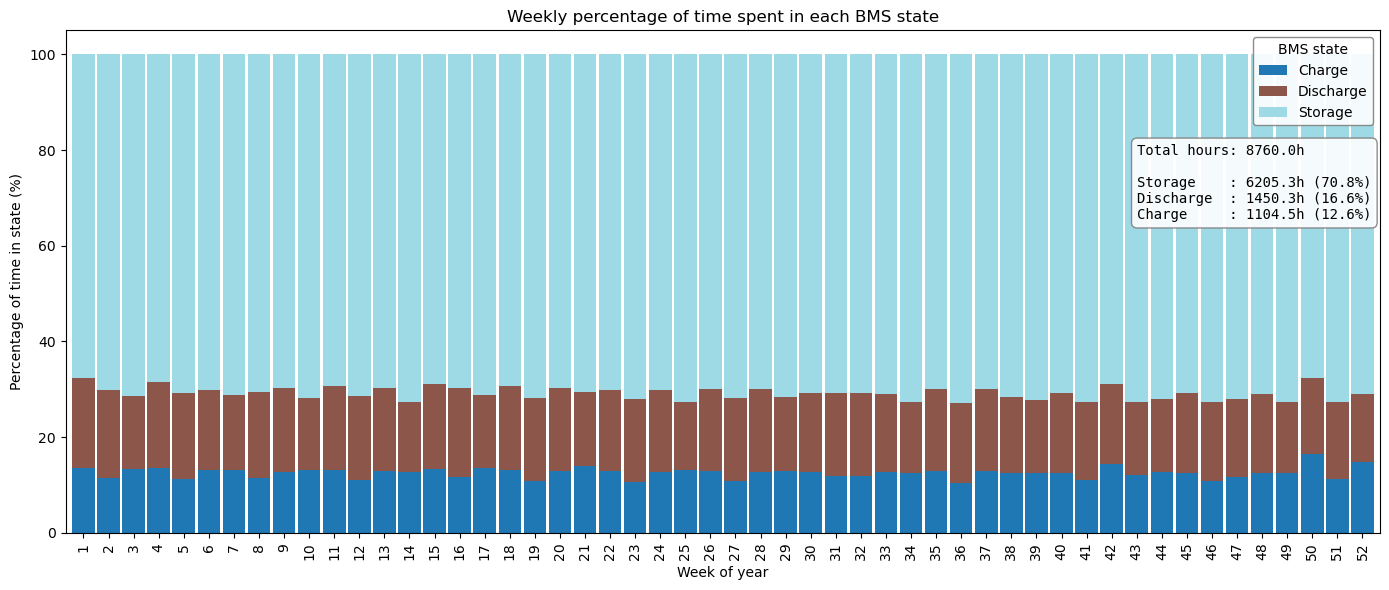

In [16]:
# Aggregate hours per week and mode
weekly = df.groupby(["week", "mode"], observed=True)["duration_h"].sum().reset_index()

# Pivot to wide table for stacked bars
weekly_pivot = weekly.pivot(index="week", columns="mode", values="duration_h").fillna(0)
weekly_pivot = weekly_pivot.sort_index()

# Convert weekly totals to percentages
weekly_pct = weekly_pivot.div(weekly_pivot.sum(axis=1), axis=0) * 100

# Year summary (hours & percentage per mode)
yearly = df.groupby("mode", observed=True)["duration_h"].sum().reset_index()
total_hours = yearly["duration_h"].sum()
yearly["pct_time"] = yearly["duration_h"] / total_hours * 100
yearly = yearly.sort_values("duration_h", ascending=False)

# Build summary text
summary_lines = [f"Total hours: {total_hours:4.1f}h\n"]
for _, row in yearly.iterrows():
    summary_lines.append(f"{row['mode']:<11s}: {row['duration_h']:4.1f}h ({row['pct_time']:2.1f}%)")
summary_text = "\n".join(summary_lines)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
weekly_pct.plot(kind="bar", stacked=True, width=0.9, ax=ax, colormap="tab20")

ax.set_xlabel("Week of year")
ax.set_ylabel("Percentage of time in state (%)")
ax.set_title("Weekly percentage of time spent in each BMS state")
legend = ax.legend(title="BMS state",
                   bbox_to_anchor=(1, 1),
                   loc="upper right",
                   frameon=True,
                   facecolor="white",
                   framealpha=0.9,
                   edgecolor="gray")

# Render the figure to compute legend position
fig.canvas.draw()

# Get legend bounding box in axes coordinates
legend_bbox = legend.get_window_extent().transformed(ax.transAxes.inverted())

# Compute text box position directly below legend, same right edge
legend_right_x = legend_bbox.x1
legend_bottom_y = legend_bbox.y0

# Add text box just below the legend 
props = dict(boxstyle="round,pad=0.4",
             facecolor="white",
             alpha=0.9,
             edgecolor="gray")

ax.text(
    legend_right_x, legend_bottom_y - 0.02,  # x ~ right edge, y just below legend
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    multialignment="left",
    bbox=props,
    family="monospace"
)

plt.tight_layout()
plt.show()



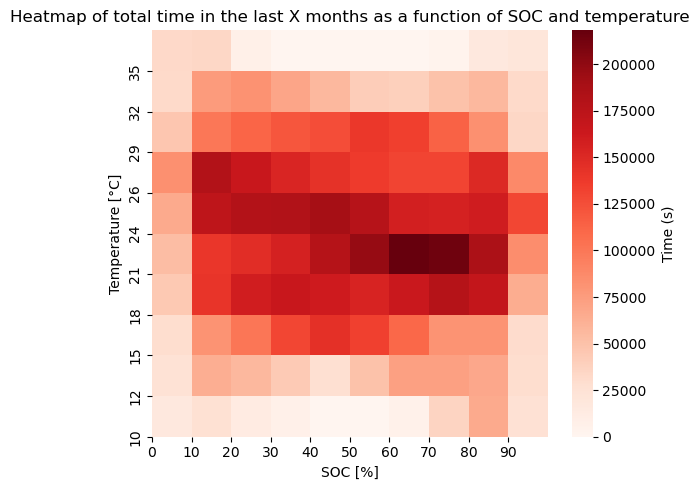

In [6]:
# ----- Heatmap of total time vs SOC and Temperature ----- #
heatmap_data, xedges, yedges = np.histogram2d(df["soc"]*100, df["temperature_M1"],
                                              bins=[10, 10], density=False)
cmap1 = sns.color_palette("Reds", as_cmap=True)
plt.figure(figsize=(6, 5))
sns.heatmap(heatmap_data.T,
            cmap=cmap1,
            cbar_kws={'label': 'Time (s)'},
            xticklabels=np.round(xedges[:-1],0),
            yticklabels=np.round(yedges[:-1],0),
            rasterized=True)
plt.gca().invert_yaxis() # High temps on top
plt.xticks(np.arange(len(xedges)-1), [f"{int(t)}" for t in xedges[:-1]])
plt.yticks(np.arange(len(yedges)-1), [f"{int(t)}" for t in yedges[:-1]])
plt.xlabel("SOC [%]")
plt.ylabel("Temperature [°C]")
plt.title("Heatmap of total time in the last X months as a function of SOC and temperature")
plt.tight_layout()
plt.show()

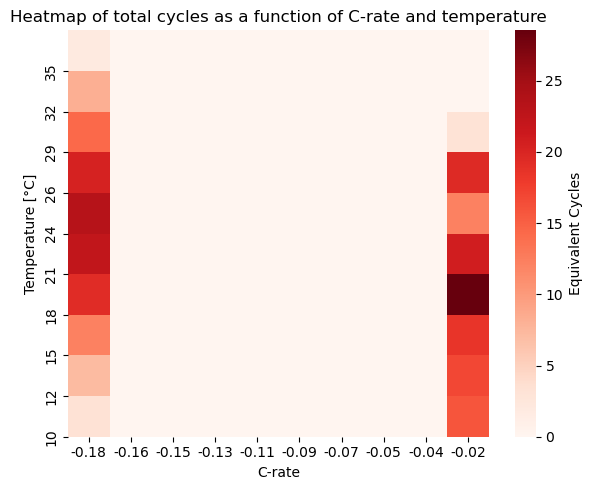

In [7]:
# ----- Heatmap of cycle count vs C-rate and Temperature ----- #
df["C_rate"] = df["batt_current"] / batt_capacity
# Focus on discharging data only (since cycle count mainly accumulates there)
discharge = df[df["mode"] == "Discharge"].copy()

# ----- Compute per-row cycle increments -----
# difference in cycle count per timestep
discharge["d_cycle"] = discharge["cycle_count"].diff().fillna(0)
# remove negative jumps (e.g. at file boundaries)
discharge.loc[discharge["d_cycle"] < 0, "d_cycle"] = 0

# ----- 2D histogram: cycle increment density over (C-rate, Temperature) -----
# You can pick which temperature sensor to use, e.g. M1 or average
temp_col = "temperature_M1"

# Define bin edges
c_bins = 10
t_bins = 10
heatmap_data, xedges, yedges = np.histogram2d(
    discharge["C_rate"],
    discharge[temp_col],
    weights=discharge["d_cycle"],
    bins=[c_bins, t_bins],
)

# ----- Plot heatmap -----
plt.figure(figsize=(6, 5))
sns.heatmap(
    heatmap_data.T,
    cmap=cmap1,
    cbar_kws={'label': 'Equivalent Cycles'},
    xticklabels=np.round(xedges[:-1], 2),
    yticklabels=np.round(yedges[:-1], 0),
    rasterized=True
)
plt.gca().invert_yaxis() # High temps on top
plt.yticks(np.arange(len(yedges)-1), [f"{int(t)}" for t in yedges[:-1]])
plt.xlabel("C-rate")
plt.ylabel("Temperature [°C]")
plt.title("Heatmap of total cycles as a function of C-rate and temperature")
plt.tight_layout()
plt.show()

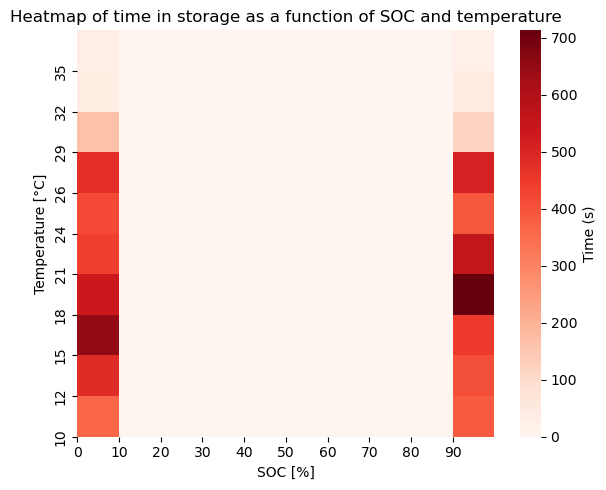

In [8]:
# ----- Heatmap of total time in storage vs SOC and Temperature ----- #
storage = df[df["mode"] == "Storage"]
heatmap_data, xedges, yedges = np.histogram2d(storage["soc"]*100, storage["temperature_M1"],
                                              bins=[10, 10], density=False)
cmap1 = sns.color_palette("Reds", as_cmap=True)
plt.figure(figsize=(6, 5))
sns.heatmap(heatmap_data.T,
            cmap=cmap1,
            cbar_kws={'label': 'Time (s)'},
            xticklabels=np.round(xedges[:-1],0),
            yticklabels=np.round(yedges[:-1],0),
            rasterized=True)
plt.gca().invert_yaxis() # High temps on top
plt.xticks(np.arange(len(xedges)-1), [f"{int(t)}" for t in xedges[:-1]])
plt.yticks(np.arange(len(yedges)-1), [f"{int(t)}" for t in yedges[:-1]])
plt.xlabel("SOC [%]")
plt.ylabel("Temperature [°C]")
plt.title("Heatmap of time in storage as a function of SOC and temperature")
plt.tight_layout()
plt.show()

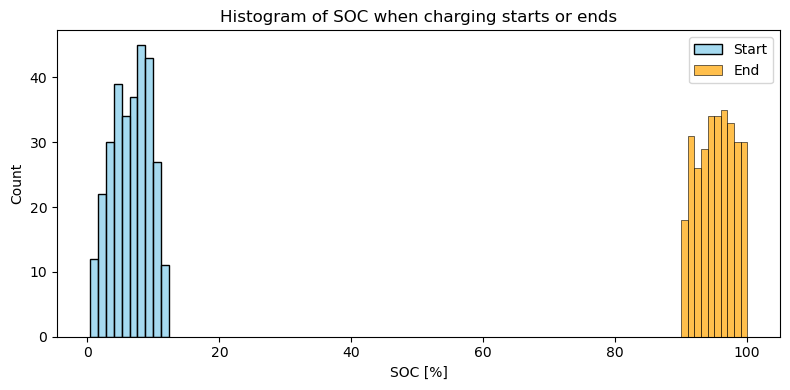

In [9]:
# ----- Histogram of SOC at charge start/end ----- #
df["prev_state"] = df["mode"].shift(1)
charge_starts = df[(df["mode"] == "Charge") & (df["prev_state"] != "Charge")]
charge_ends = df[(df["mode"] != "Charge") & (df["prev_state"] == "Charge")]

plt.figure(figsize=(8,4))
sns.histplot(charge_starts["soc"]*100, bins=10, color='skyblue', label='Start')
sns.histplot(charge_ends["soc"]*100, bins=10, color='orange', label='End', alpha=0.7)
plt.xlabel("SOC [%]")
plt.ylabel("Count")
plt.title("Histogram of SOC when charging starts or ends")
plt.legend()
plt.tight_layout()
plt.show()

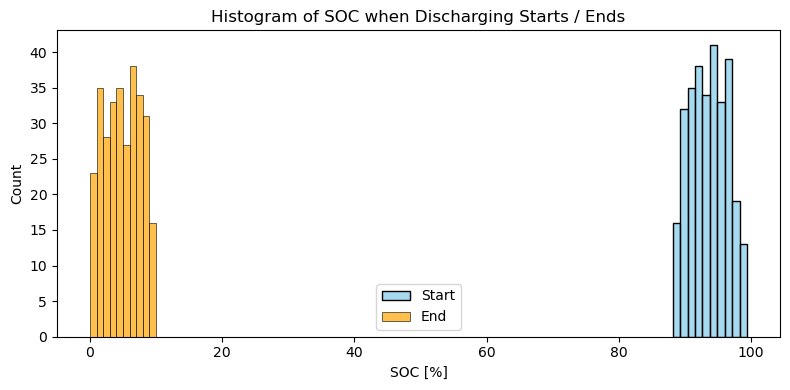

In [10]:
# ----- Histogram of SOC at discharge start/end ----- #
discharge_starts = df[(df["mode"] == "Discharge") & (df["prev_state"] != "Discharge")]
discharge_ends = df[(df["mode"] != "Discharge") & (df["prev_state"] == "Discharge")]

plt.figure(figsize=(8,4))
sns.histplot(discharge_starts["soc"]*100, bins=10, color='skyblue', label='Start')
sns.histplot(discharge_ends["soc"]*100, bins=10, color='orange', label='End', alpha=0.7)
plt.xlabel("SOC [%]")
plt.ylabel("Count")
plt.title("Histogram of SOC when Discharging Starts / Ends")
plt.legend()
plt.tight_layout()
plt.show()